In [ ]:
!pip install bertopic
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu

In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
from sentence_transformers import SentenceTransformer

In [ ]:
# gunakan embedding model dari IndoBERT
embedding_model = SentenceTransformer("indobenchmark/indobert-base-p1")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# import data
df = pd.read_csv('/content/result_2.csv')
df

# filter
df_filtered = df[df['title'] == 'RST Slamet Riyadi']
display(df_filtered)

,title,stars,text,bin_pelayanan,bin_fasilitas,predicted_labels_1,labels,prob_layanan,prob_fasilitas
5834,RST Slamet Riyadi,5,selalu puas sama pelayanan di sini apalagi bua...,1,0,['pelayanan'],positive,0.997583,0.005477
5835,RST Slamet Riyadi,5,rumah sakit bagus peralatan medis lengkapdokte...,1,1,"['pelayanan', 'fasilitas']",positive,0.995894,0.992098
5836,RST Slamet Riyadi,5,tempat yang sangat nyaman untuk proses penyemb...,1,1,"['pelayanan', 'fasilitas']",positive,0.996908,0.988680
5837,RST Slamet Riyadi,5,pelayanan medis cepat dan ramah dokter profesi...,1,1,"['pelayanan', 'fasilitas']",positive,0.997341,0.987433
5838,RST Slamet Riyadi,5,dokternya sangat komunikatif dan sabar menjela...,1,0,['pelayanan'],positive,0.998085,0.007391
...,...,...,...,...,...,...,...,...,...
6361,RST Slamet Riyadi,5,sedang dalam renovasi,0,1,['fasilitas'],neutral,0.006170,0.992200
6362,RST Slamet Riyadi,1,duplikat,1,1,"['pelayanan', 'fasilitas']",negative,0.939014,0.990032
6363,RST Slamet Riyadi,5,benar2 puas dengan pelayanan di rs dkt surakar...,1,0,['pelayanan'],positive,0.998274,0.031327
6364,RST Slamet Riyadi,4,DKT Solo,0,1,['fasilitas'],neutral,0.001040,0.628741


In [ ]:
# menghapus stopwords
import re

# daftar
stopwords = ['saya', 'yg', 'dan', 'yang', 'di', 'tidak', 'juga', 'utk', 'itu',
             'untuk', 'juga', 'jg', 'nya', 'tapi', 'tp', 'ga', 'gak', 'ngga', 'nggak', 'sy', 'lagi',
             'lg', 'dengan', 'dgn', 'dg', 'ini', 'kami', 'apa', 'ada', 'ke', 'ya', 'dong', 'sgt', 'bgt',
             'karena', 'krn', 'sebagai', 'sbg', 'dari', 'malah']

# function
def remove_stopwords(text):
    if isinstance(text, str):  # make sure string
        pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
        return re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return text


df_filtered['text'] = df_filtered['text'].apply(remove_stopwords)

# Kategori

In [ ]:
# insialisasi model untuk dua kategori
layanan_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)
fasilitas_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan probabilitas kategori
def assign_reviews_by_category(data, threshold=0.5):
    layanan_reviews = []
    fasilitas_reviews = []
    layanan_indices = []
    fasilitas_indices = []
    for idx, row in data.iterrows():
        if row['prob_layanan'] >= threshold:
            layanan_reviews.append(row['text'])
            layanan_indices.append(idx)
        if row['prob_fasilitas'] >= threshold:
            fasilitas_reviews.append(row['text'])
            fasilitas_indices.append(idx)
    return layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices

# Memisahkan ulasan (ulasan dengan prob 0.99 masuk ke kedua kategori)
layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices = assign_reviews_by_category(df_filtered, threshold=0.5)

In [ ]:
# Pemodelan topik untuk kategori layanan
if layanan_reviews:
    topics_layanan, probs_layanan = layanan_model.fit_transform(layanan_reviews)
else:
    topics_layanan, probs_layanan = [], []

In [ ]:
# Pemodelan topik untuk kategori fasilitas
if fasilitas_reviews:
    topics_fasilitas, probs_fasilitas = fasilitas_model.fit_transform(fasilitas_reviews)
else:
    topics_fasilitas, probs_fasilitas = [], []

In [ ]:
# layanan_model.update_topics(layanan_reviews, top_n_words=10)  # Batasi ke 10 kata
# fasilitas_model.update_topics(fasilitas_reviews, top_n_words=10)  # Batasi ke 10 kata

## Hasil topic modelling

In [ ]:
# melihat total topic layanan
print(len(layanan_model.get_topics()))

# melihat total topic fasilitas
print(len(fasilitas_model.get_topics()))

2
2


In [ ]:
layanan_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,112,0_pelayanan_bagus_baik_sangat,"[pelayanan, bagus, baik, sangat, ramah, memuas...","[pelayanan sangat bagus, pelayanan sangat bag..."
1,1,366,1_ramah_pelayanan_rumah_sakit,"[ramah, pelayanan, rumah, sakit, sangat, rs, b...",[rumah sakit pelayanannya sangat baik petuga...


In [ ]:
fasilitas_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,72,0_riyadi_bagus_slamet_rumah,"[riyadi, bagus, slamet, rumah, sakit, terbaik,...",[rst slamet riyadi dkt rumah sakit umum kota ...
1,1,185,1_rumah_pelayanan_ramah_sakit,"[rumah, pelayanan, ramah, sakit, bersih, sanga...",[pelayanan ramah baik cepat rumah sakit selalu...


## Frekuensi sentimen dari setiap topik

In [ ]:
import numpy as np
import pandas as pd

# === Analisis Topik & Sentimen untuk Layanan ===
# Pastikan indeks valid
layanan_indices_valid = np.intersect1d(layanan_indices, df_filtered.index)

df_layanan = df_filtered.loc[layanan_indices_valid].copy()
df_layanan["topic"] = topics_layanan[:len(df_layanan)]  # pastikan panjang sama

df_layanan = df_layanan[df_layanan['topic'] != -1]
topic_sentiment_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'])
emotion_dist_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'], normalize='index')

print("=== Distribusi Sentimen per Topik (Layanan) ===")
print(topic_sentiment_layanan)
print("\n=== Proporsi Sentimen per Topik (Layanan) ===")
print(emotion_dist_layanan)


# === Analisis Topik & Sentimen untuk Fasilitas ===
# Pastikan indeks valid
fasilitas_indices_valid = np.intersect1d(fasilitas_indices, df_filtered.index)

df_fasilitas = df_filtered.loc[fasilitas_indices_valid].copy()
df_fasilitas["topic"] = topics_fasilitas[:len(df_fasilitas)]  # pastikan panjang sama

df_fasilitas = df_fasilitas[df_fasilitas['topic'] != -1]
topic_sentiment_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'])
emotion_dist_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'], normalize='index')

print("\n=== Distribusi Sentimen per Topik (Fasilitas) ===")
print(topic_sentiment_fasilitas)
print("\n=== Proporsi Sentimen per Topik (Fasilitas) ===")
print(emotion_dist_fasilitas)


=== Distribusi Sentimen per Topik (Layanan) ===
labels  negative  neutral  positive
topic                              
0             12        7        93
1             58       21       287

=== Proporsi Sentimen per Topik (Layanan) ===
labels  negative   neutral  positive
topic                               
0       0.107143  0.062500  0.830357
1       0.158470  0.057377  0.784153

=== Distribusi Sentimen per Topik (Fasilitas) ===
labels  negative  neutral  positive
topic                              
0              9       15        48
1             25        7       153

=== Proporsi Sentimen per Topik (Fasilitas) ===
labels  negative   neutral  positive
topic                               
0       0.125000  0.208333  0.666667
1       0.135135  0.037838  0.827027


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

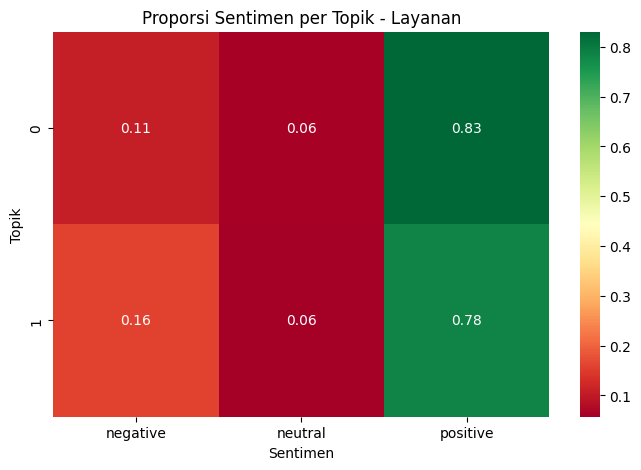

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_layanan, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Layanan")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

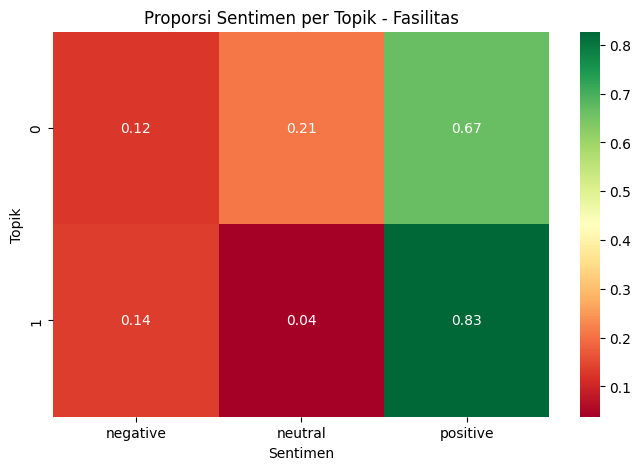

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_fasilitas, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Fasilitas")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

In [ ]:
# Fungsi untuk menampilkan kata kunci tiap topik
def tampilkan_topik(model, kategori):
    topics = model.get_topics()
    print(f"=== Topik untuk kategori {kategori} ===")
    for topic_id, topic_info in topics.items():
        print(f"Topic {topic_id}:")
        print(f"Representasi: {topic_info}")
        print("-" * 50)
    print("\n")

# Panggil untuk layanan dan fasilitas
tampilkan_topik(layanan_model, "Layanan")
tampilkan_topik(fasilitas_model, "Fasilitas")

=== Topik untuk kategori Layanan ===
Topic 0:
Representasi: [('pelayanan', np.float64(0.40412092683557366)), ('bagus', np.float64(0.30400765918156397)), ('baik', np.float64(0.24844160283946898)), ('sangat', np.float64(0.23110848237790255)), ('ramah', np.float64(0.19219541759997968)), ('memuaskan', np.float64(0.17917558716212426)), ('pelayanannya', np.float64(0.1755792954994223)), ('buruk', np.float64(0.10991901051098801)), ('biasa', np.float64(0.08919058705837084)), ('semakin', np.float64(0.07679503925545132))]
--------------------------------------------------
Topic 1:
Representasi: [('ramah', np.float64(0.07025866739088038)), ('pelayanan', np.float64(0.06973261553915688)), ('rumah', np.float64(0.05982420463697996)), ('sakit', np.float64(0.05838767211055272)), ('sangat', np.float64(0.05401553246359238)), ('rs', np.float64(0.05132678012320541)), ('baik', np.float64(0.049033220312600746)), ('dokter', np.float64(0.04360915077483709)), ('bagus', np.float64(0.04070790550263145)), ('pasien'

# Sentimen

In [ ]:
# insialisasi model untuk dua sentimen
positive_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=8)
negative_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=6)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan sentimen
def assign_reviews_by_sentiment(data):
    positif_reviews = data[data['labels'] == 'positive']['text'].tolist()
    negatif_reviews = data[data['labels'] == 'negative']['text'].tolist()
    positif_indices = data[data['labels'] == 'positive'].index.tolist()
    negatif_indices = data[data['labels'] == 'negative'].index.tolist()
    return positif_reviews, negatif_reviews, positif_indices, negatif_indices

In [ ]:
# Memisahkan ulasan berdasarkan sentimen
positif_reviews, negatif_reviews, positif_indices, negatif_indices = assign_reviews_by_sentiment(df_filtered)

In [ ]:
# Pemodelan topik untuk sentimen positif
if positif_reviews:
    topics_positif, probs_positif = positive_model.fit_transform(positif_reviews)
else:
    topics_positif, probs_positif = [], []

In [ ]:
# Pemodelan topik untuk sentimen negatif
if negatif_reviews:
    topics_negatif, probs_negatif = negative_model.fit_transform(negatif_reviews)
else:
    topics_negatif, probs_negatif = [], []

## Hasil Topic Modelling

In [ ]:
# melihat total topic positive
print(len(positive_model.get_topics()))

# melihat total topic negative
print(len(negative_model.get_topics()))

3
2


In [ ]:
positive_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7,-1_terbaik_sakit_rumah_tentara,"[terbaik, sakit, rumah, tentara, stroke, berse...","[rumah sakit terbaik terapi stroke, rumah sak..."
1,0,98,0_pelayanan_bagus_baik_sangat,"[pelayanan, bagus, baik, sangat, memuaskan, ra...","[pelayanan sangat bagus, pelayanan bagus rama..."
2,1,302,1_ramah_pelayanan_rumah_sakit,"[ramah, pelayanan, rumah, sakit, baik, sangat,...","[perawat ramah baik rumah sakit bersih, pelay..."


In [ ]:
negative_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,16,0_buruk_sangat_pelayanan_duplikat,"[buruk, sangat, pelayanan, duplikat, sakitnya,...","[pelayanan buruk, pelayanan buruk, pelayanan s..."
1,1,61,1_pasien_pelayanan_dokter_sangat,"[pasien, pelayanan, dokter, sangat, rs, sakit,...",[rumah sakit tempatnya strategis menghadap 2...


In [ ]:
# Panggil untuk layanan dan fasilitas
tampilkan_topik(positive_model, "Positif")
tampilkan_topik(negative_model, "Negatif")

=== Topik untuk kategori Positif ===
Topic -1:
Representasi: [('terbaik', np.float64(0.6701106176114627)), ('sakit', np.float64(0.6014792360578496)), ('rumah', np.float64(0.5792570886360987)), ('tentara', np.float64(0.38423722505008023)), ('stroke', np.float64(0.26623999819157146)), ('bersejarah', np.float64(0.26623999819157146)), ('terapi', np.float64(0.26623999819157146)), ('pilihan', np.float64(0.24150540375440518)), ('paling', np.float64(0.22704515710084697)), ('keluarga', np.float64(0.20884264916743855))]
--------------------------------------------------
Topic 0:
Representasi: [('pelayanan', np.float64(0.3094738115872286)), ('bagus', np.float64(0.27051969901926387)), ('baik', np.float64(0.22125834227855726)), ('sangat', np.float64(0.16780240748642006)), ('memuaskan', np.float64(0.1608770020367654)), ('ramah', np.float64(0.15726333504629164)), ('pelayanannya', np.float64(0.13743715793314495)), ('luar', np.float64(0.0720654097228038)), ('biasa', np.float64(0.07083500163083675)), ('